In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.tsa.api as smt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
data = pd.read_csv('exchange_rate.csv', parse_dates=['date'],dayfirst=True, index_col='date')
data = data.asfreq('Y').fillna(method='ffill')

In [3]:
data.head()

,Ex_rate
date,
1990-12-31,0.7650
1991-12-31,0.6720
1992-12-31,0.7415
1993-12-31,0.7318
1994-12-31,0.7525


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 20 entries, 1990-12-31 to 2009-12-31
Freq: YE-DEC
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  20 non-null     float64
dtypes: float64(1)
memory usage: 320.0 bytes


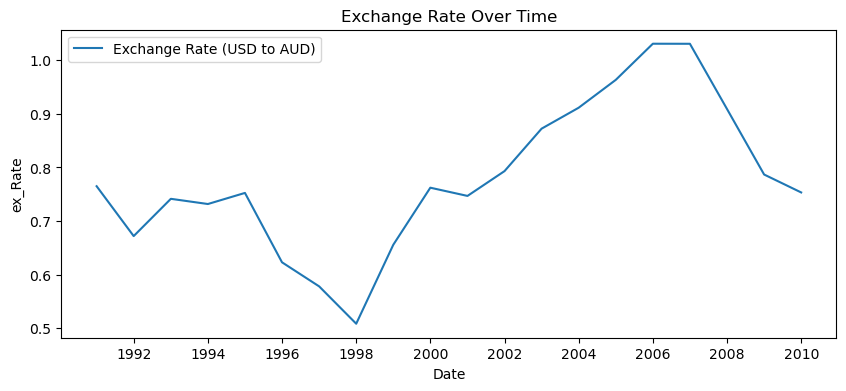

In [5]:
plt.figure(figsize=(10,4))
plt.plot(data['Ex_rate'], label='Exchange Rate (USD to AUD)')
plt.title('Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('ex_Rate')
plt.legend()
plt.show()

In [6]:
# Check missing values
data.isna().sum()

Ex_rate    0
dtype: int64

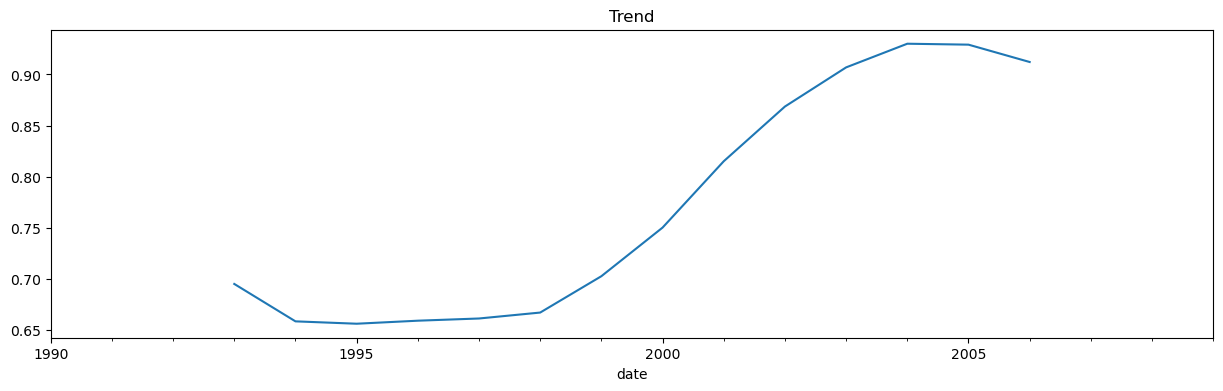

In [7]:
# Seasonal Decomposition
plt.figure(figsize=(15,4))
decomp = seasonal_decompose(data['Ex_rate'], model='multiplicative', period=7)
decomp.trend.plot(title='Trend')
plt.show()

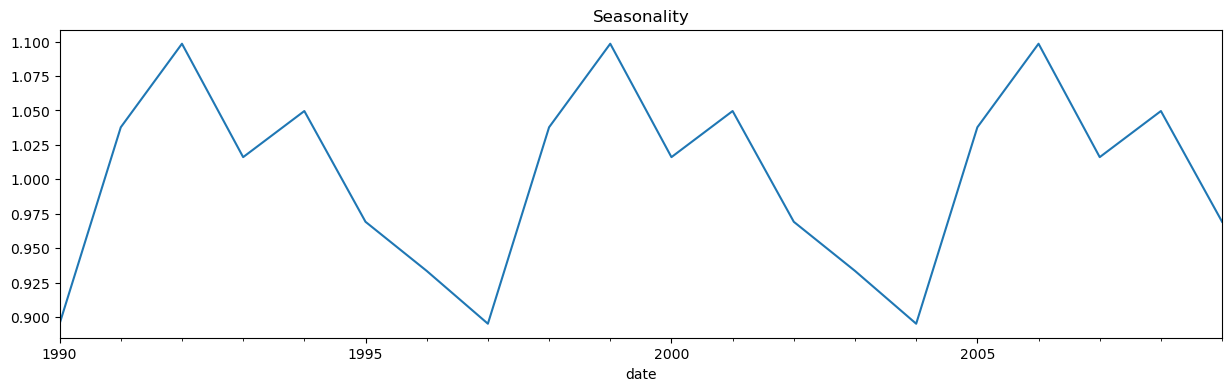

In [8]:
plt.figure(figsize=(15,4))
decomp.seasonal.plot(title='Seasonality')
plt.show()

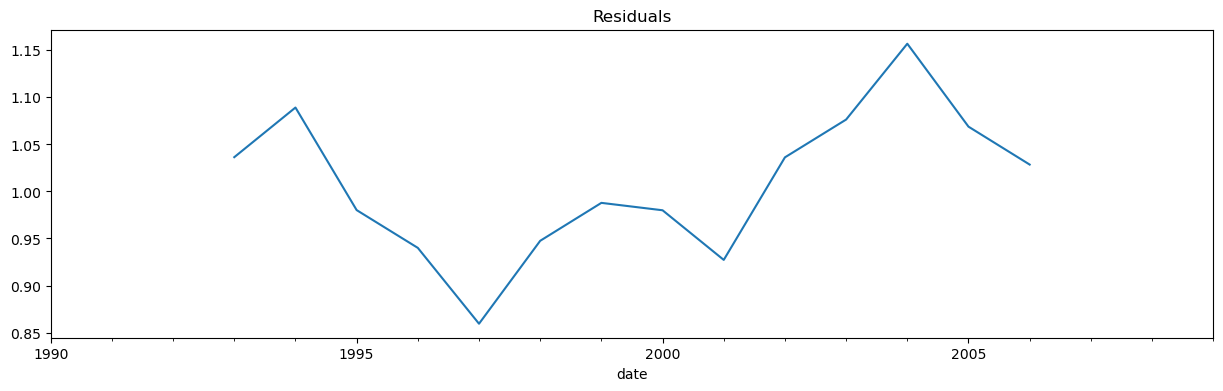

In [9]:
plt.figure(figsize=(15,4))
decomp.resid.plot(title='Residuals')
plt.show()

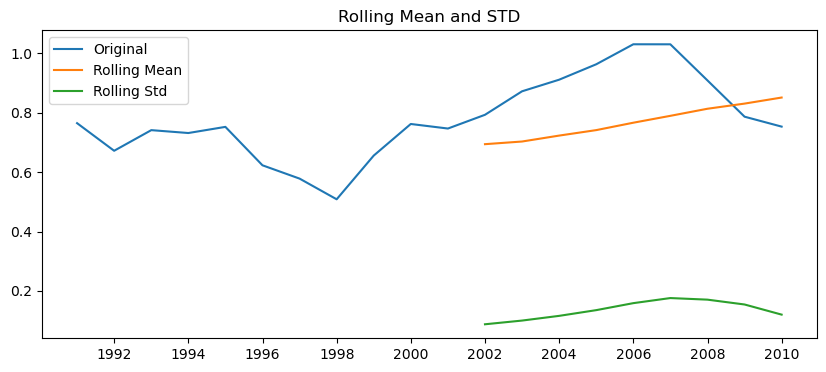

ADF Statistic: -9.076852927369565
p-value: 4.156812860339109e-15
Critical Values:
1% -4.223238279489106
5% -3.189368925619835
10% -2.729839421487603


In [10]:
# Stationarity Check Function
def stationarity_test(series):
    rolling_mean = series.rolling(window=12).mean()
    rolling_std = series.rolling(window=12).std()

    plt.figure(figsize=(10,4))
    plt.plot(series, label='Original')
    plt.plot(rolling_mean, label='Rolling Mean')
    plt.plot(rolling_std, label='Rolling Std')
    plt.title('Rolling Mean and STD')
    plt.legend()
    plt.show()

    adf = adfuller(series)
    print("ADF Statistic:", adf[0])
    print("p-value:", adf[1])
    print("Critical Values:")
    for key,val in adf[4].items():
        print(key, val)

stationarity_test(data['Ex_rate'])

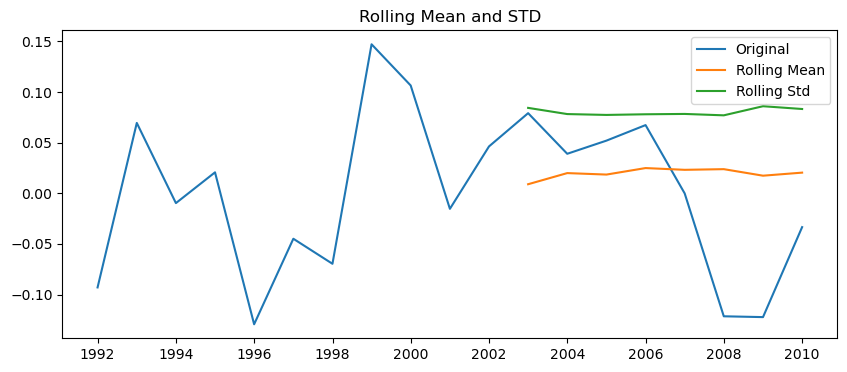

ADF Statistic: -2.3942045500273723
p-value: 0.14337881734513658
Critical Values:
1% -3.9240193847656246
5% -3.0684982031250003
10% -2.67389265625


In [11]:
# Differencing
data['Diff'] = data['Ex_rate'].diff()
data=data.dropna(subset=['Diff'])
stationarity_test(data['Diff'])

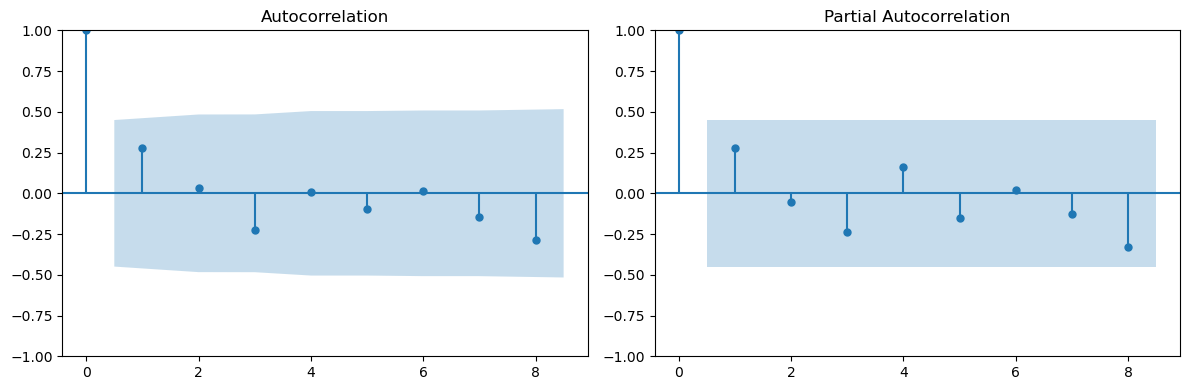

In [12]:
# ACF and PACF
fig, axes = plt.subplots(1,2, figsize=(12,4))
smt.graphics.plot_acf(data['Diff'], lags=8, ax=axes[0])
smt.graphics.plot_pacf(data['Diff'], lags=8, ax=axes[1])
plt.tight_layout()
plt.show()

In [13]:
# ARIMA Model
model_arima = ARIMA(data['Ex_rate'], order=(2,1,1))
fit_arima = model_arima.fit()
data['ARIMA_Pred'] = fit_arima.predict()

forecast_arima = fit_arima.forecast(20)

D:\sujal\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


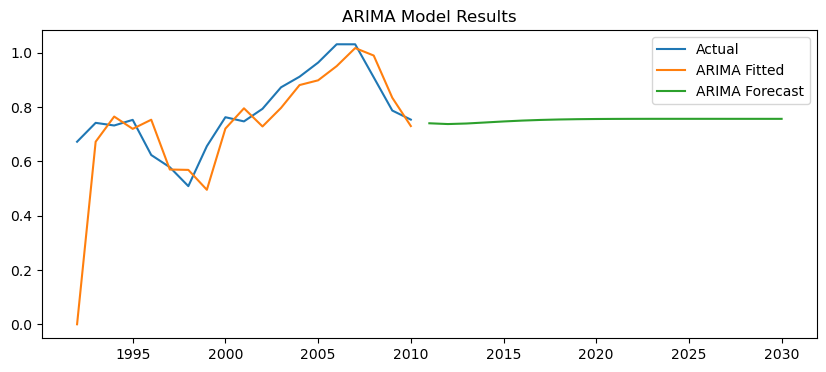

In [14]:
plt.figure(figsize=(10,4))
plt.plot(data['Ex_rate'], label='Actual')
plt.plot(data['ARIMA_Pred'], label='ARIMA Fitted')
plt.plot(forecast_arima, label='ARIMA Forecast')
plt.title('ARIMA Model Results')
plt.legend()
plt.show()

In [15]:
# Exponential Smoothing Model
hw_model = ExponentialSmoothing(data['Ex_rate'], trend='add', seasonal=None)
hw_fit = hw_model.fit()
data['HW_Pred'] = hw_fit.fittedvalues
forecast_hw = hw_fit.forecast(20)


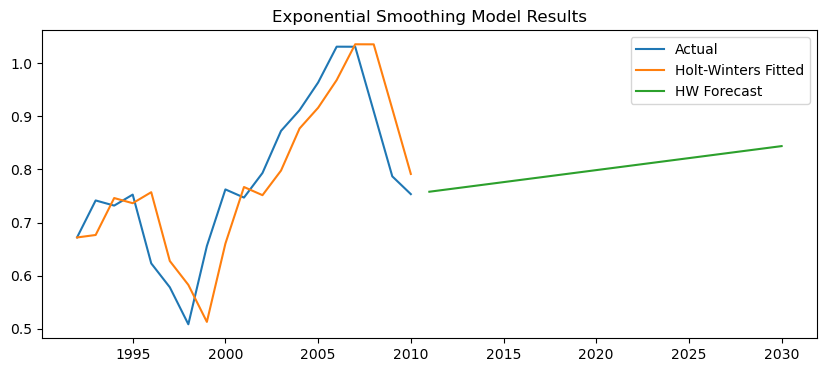

In [16]:
plt.figure(figsize=(10,4))
plt.plot(data['Ex_rate'], label='Actual')
plt.plot(data['HW_Pred'], label='Holt-Winters Fitted')
plt.plot(forecast_hw, label='HW Forecast')
plt.title('Exponential Smoothing Model Results')
plt.legend()
plt.show()

In [17]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

arima_scores = evaluate(data['Ex_rate'], data['ARIMA_Pred'])
hw_scores = evaluate(data['Ex_rate'], data['HW_Pred'])

print("ARIMA -> MAE:", arima_scores[0], "RMSE:", arima_scores[1], "MAPE:", arima_scores[2])
print("Holt-Winters -> MAE:", hw_scores[0], "RMSE:", hw_scores[1], "MAPE:", hw_scores[2])

ARIMA -> MAE: 0.09148639432166339 RMSE: 0.1685920002854116 MAPE: 12.783500967226033
Holt-Winters -> MAE: 0.061802864335093785 RMSE: 0.07604041563744099 MAPE: 8.389569834834147
